  CNN Fund Movement Regression — Trade Influence
  Device : cpu

[1/5] Loading data ...
  Train windows : 204  |  Val windows : 10

[2/5] Building model ...
  Trainable parameters : 159,361

[3/5] Training ...
 Epoch  Train Loss   Val Loss   Val MAE   Dir Acc
────────────────────────────────────────────────────
     1     0.00976    0.00608   0.61305    20.00%
     5     0.00761    0.00528   0.53326    80.00%
    10     0.00540    0.00487   0.49223    80.00%
    15     0.00396    0.00485   0.49023    80.00%
    20     0.00340    0.00493   0.49847    80.00%
    25     0.00285    0.00513   0.51811    70.00%
    30     0.00242    0.00582   0.58676    60.00%
    35     0.00214    0.00442   0.44716    80.00%
    40     0.00189    0.00506   0.51141    60.00%
────────────────────────────────────────────────────
  Best directional accuracy : 80.00%
  Best val MAE              : 0.41898

[4/5] Computing trade saliency (Grad-CAM) ...

  Top 10 Most Influential Trades:
 trade_idx  saliency  signe

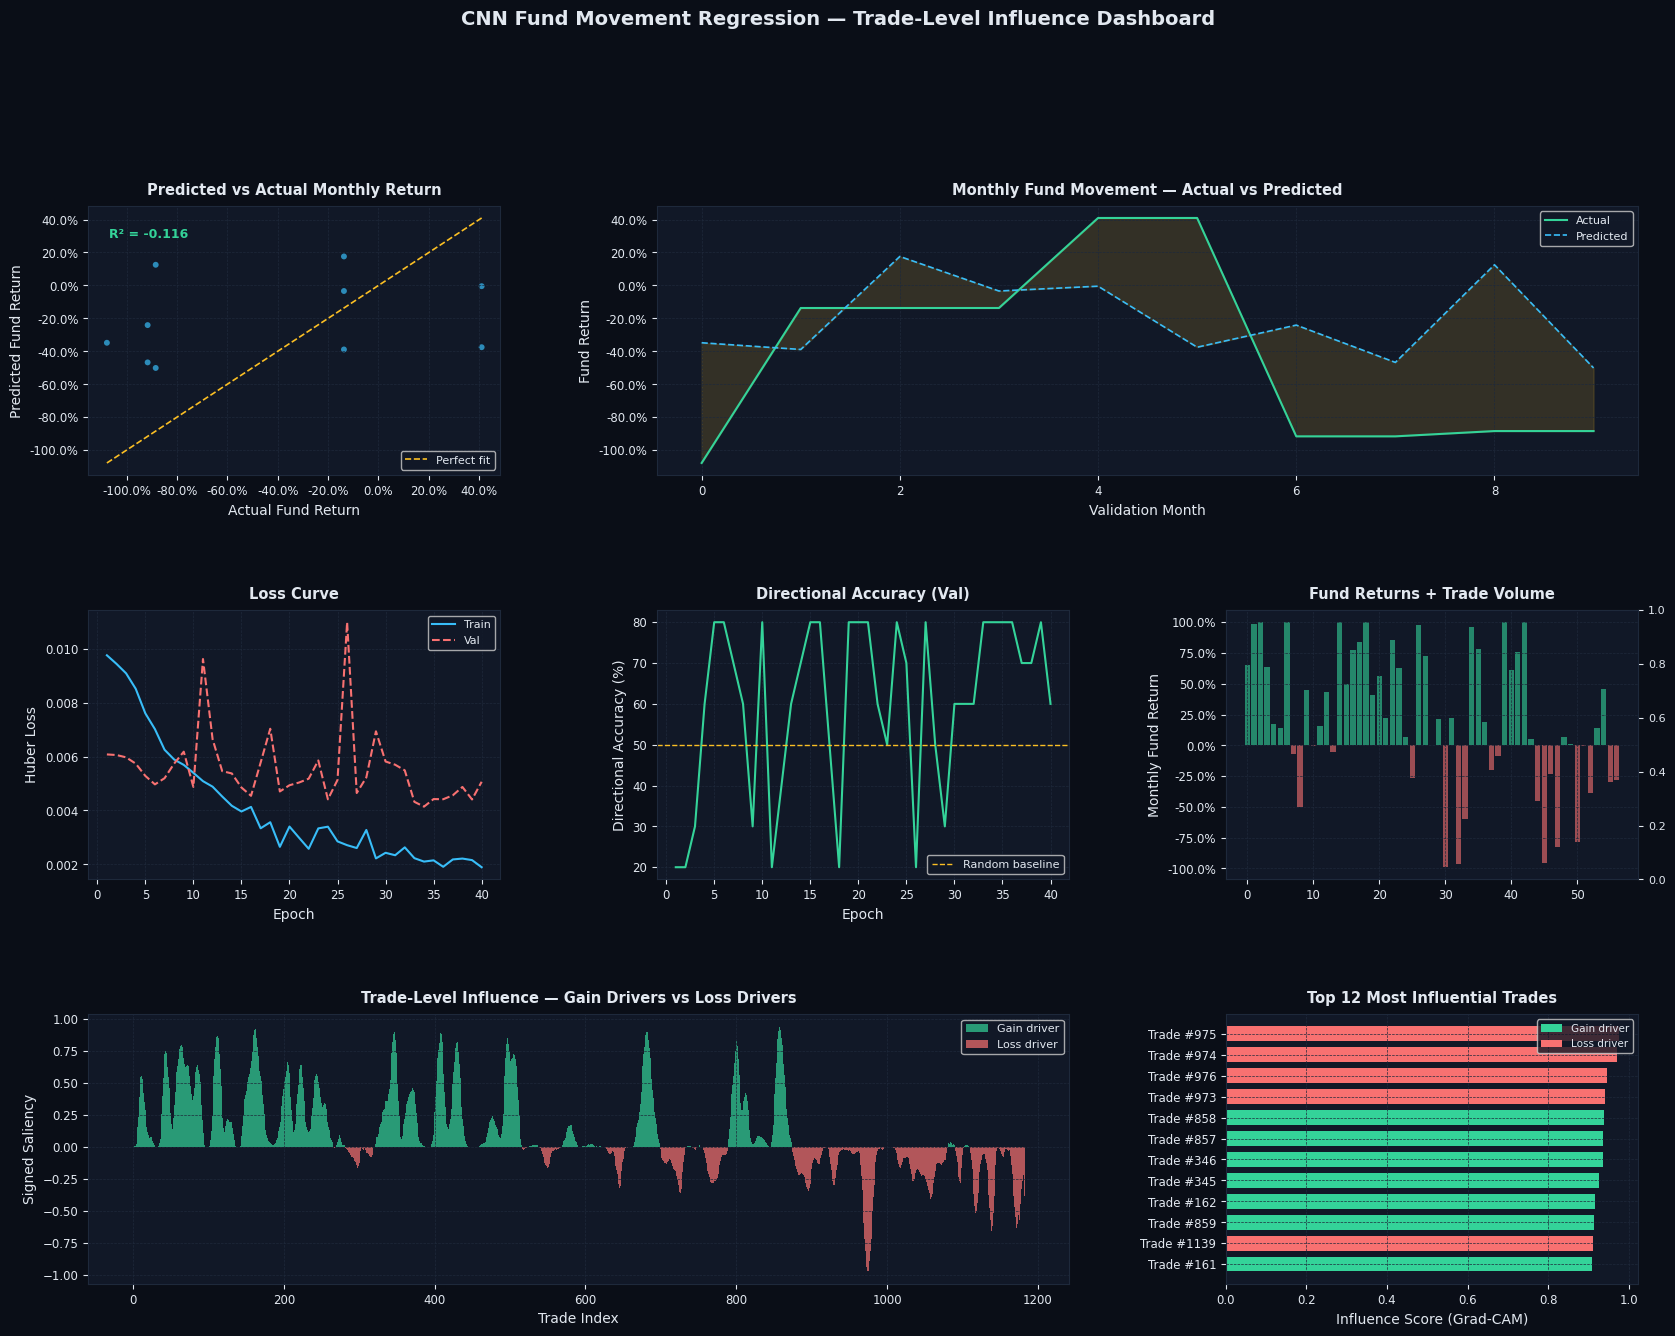

Saved → cnn_fund_results.png


In [3]:
"""
CNN for Financial Time Series — Fund Movement Regression
=========================================================
Maps a window of individual trades → predicted monthly fund movement (continuous).
Grad-CAM saliency identifies which trades most influenced the fund's direction.

Target  : monthly % change in fund NAV / holdings value (continuous, not binary)
Input   : sliding window of trade-level features, aligned to monthly periods
"""

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────
#  1.  DATASET  (trade-window → monthly return)
# ─────────────────────────────────────────────

class FundMovementDataset(Dataset):
    """
    Each sample is a window of consecutive trades mapped to the
    fund's return for the month those trades fall in.

    Parameters
    ----------
    trade_features : np.ndarray  (N_trades, F)
    trade_months   : np.ndarray  (N_trades,)   integer month index per trade
    monthly_returns: np.ndarray  (N_months,)   continuous fund return per month
    window         : int                        trades per sample
    stride         : int                        sliding window stride
    """

    def __init__(self, trade_features: np.ndarray, trade_months: np.ndarray,
                 monthly_returns: np.ndarray, window: int = 60, stride: int = 5):
        self.X       = torch.tensor(trade_features, dtype=torch.float32)
        self.months  = trade_months
        self.returns = monthly_returns
        self.window  = window
        self.stride  = stride

        # Build valid index list: only windows that have a known monthly return
        self.indices = []
        for start in range(0, len(self.X) - window + 1, stride):
            end = start + window - 1
            month_idx = int(self.months[end])
            if month_idx < len(self.returns):  # <-- was len(monthly_returns)
                self.indices.append((start, month_idx))

                

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start, month_idx = self.indices[idx]
        x = self.X[start : start + self.window].T          # (F, window)
        y = torch.tensor(self.returns[month_idx], dtype=torch.float32)
        return x, y, start                                  # return start for saliency alignment


# ─────────────────────────────────────────────
#  2.  MODEL  (regression output)
# ─────────────────────────────────────────────

class FundCNN(nn.Module):
    """
    1-D CNN that regresses a window of trades onto a single continuous
    fund-movement value (monthly % return).

    Architecture
    ------------
    Block 1 : Conv1d(F → 64,  k=7) → BN → GELU → MaxPool(2)
    Block 2 : Conv1d(64 → 128, k=5) → BN → GELU → MaxPool(2)
    Block 3 : Conv1d(128 → 256, k=3) → BN → GELU ← Grad-CAM target
    Head    : AdaptiveAvgPool → Flatten → Dropout → Linear(256→64) → Linear(64→1)
    """

    def __init__(self, in_channels: int, base_filters: int = 64, dropout: float = 0.3):
        super().__init__()

        self.block1 = self._conv_block(in_channels,      base_filters,     kernel=7, pool=True)
        self.block2 = self._conv_block(base_filters,     base_filters * 2, kernel=5, pool=True)
        self.block3 = self._conv_block(base_filters * 2, base_filters * 4, kernel=3, pool=False)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base_filters * 4, 64),
            nn.GELU(),
            nn.Linear(64, 1)          # ← single continuous output
        )

        # Grad-CAM hooks on last conv layer
        self._activations = None
        self._gradients   = None
        self.block3[0].register_forward_hook(self._save_activation)
        self.block3[0].register_full_backward_hook(self._save_gradient)

    @staticmethod
    def _conv_block(in_ch, out_ch, kernel, pool):
        layers = [
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel, padding=kernel // 2),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
        ]
        if pool:
            layers.append(nn.MaxPool1d(kernel_size=2, stride=2))
        return nn.Sequential(*layers)

    def _save_activation(self, _, __, output):
        self._activations = output

    def _save_gradient(self, _, __, grad_output):
        self._gradients = grad_output[0]

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.global_pool(x)
        return self.head(x).squeeze(-1)      # (B,)

    # ── Grad-CAM for regression ───────────────────────────────────────────

    def grad_cam(self, x: torch.Tensor) -> np.ndarray:
        """
        Saliency map for a regression target: gradient of the predicted
        fund return w.r.t. the final conv feature maps.

        Returns array of shape (window,) — higher = more influential trade.
        """
        self.zero_grad()
        pred = self(x)                               # scalar prediction per sample
        pred.sum().backward()                        # sum OK for single-sample batches

        weights = self._gradients.mean(dim=-1, keepdim=True)   # (B, C, 1)
        cam     = (weights * self._activations).sum(dim=1)      # (B, T')
        cam     = F.relu(cam)

        original_len = x.shape[-1]
        cam = F.interpolate(cam.unsqueeze(1), size=original_len,
                            mode='linear', align_corners=False).squeeze()
        cam = cam.detach().cpu().numpy()
        if cam.ndim == 0:
            cam = cam.reshape(1)
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam


# ─────────────────────────────────────────────
#  3.  TRAINER  (regression metrics)
# ─────────────────────────────────────────────

class RegressionTrainer:

    def __init__(self, model: FundCNN, lr: float = 1e-3, device: str = "cpu"):
        self.model   = model.to(device)
        self.device  = device
        self.opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        self.sched   = torch.optim.lr_scheduler.OneCycleLR(
                            self.opt, max_lr=lr, total_steps=500, pct_start=0.2)
        # Huber loss — less sensitive to outlier months than pure MSE
        self.loss_fn = nn.HuberLoss(delta=0.01)

        self.history = {k: [] for k in
                        ["train_loss", "val_loss", "val_mae", "val_dir_acc"]}

    def _run_epoch(self, loader, train=True):
        self.model.train(train)
        all_preds, all_targets = [], []
        total_loss, n = 0.0, 0
        ctx = torch.enable_grad if train else torch.no_grad

        with ctx():
            for xb, yb, _ in loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                preds  = self.model(xb)
                loss   = self.loss_fn(preds, yb)

                if train:
                    self.opt.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                    self.opt.step()
                    if self.sched is not None:
                        try: self.sched.step()
                        except: pass

                total_loss += loss.item() * len(xb)
                n          += len(xb)
                all_preds.extend(preds.detach().cpu().numpy())
                all_targets.extend(yb.cpu().numpy())

        preds_arr   = np.array(all_preds)
        targets_arr = np.array(all_targets)
        mae         = mean_absolute_error(targets_arr, preds_arr)
        dir_acc     = np.mean(np.sign(preds_arr) == np.sign(targets_arr))   # directional accuracy

        return total_loss / n, mae, dir_acc, preds_arr, targets_arr

    def fit(self, train_loader, val_loader, epochs: int = 40):
        print(f"{'Epoch':>6} {'Train Loss':>11} {'Val Loss':>10} "
              f"{'Val MAE':>9} {'Dir Acc':>9}")
        print("─" * 52)

        for epoch in range(1, epochs + 1):
            tr_loss, _,       _,       _,  _  = self._run_epoch(train_loader, train=True)
            va_loss, va_mae, va_dir, vp, vt   = self._run_epoch(val_loader,   train=False)

            self.history["train_loss"].append(tr_loss)
            self.history["val_loss"].append(va_loss)
            self.history["val_mae"].append(va_mae)
            self.history["val_dir_acc"].append(va_dir)

            if epoch % 5 == 0 or epoch == 1:
                print(f"{epoch:>6}  {tr_loss:>10.5f}  {va_loss:>9.5f}  "
                      f"{va_mae:>8.5f}  {va_dir:>8.2%}")

        print("─" * 52)
        best_dir = max(self.history["val_dir_acc"])
        print(f"  Best directional accuracy : {best_dir:.2%}")
        print(f"  Best val MAE              : {min(self.history['val_mae']):.5f}")

        # Return final val predictions for plotting
        _, _, _, val_preds, val_targets = self._run_epoch(val_loader, train=False)
        return val_preds, val_targets


# ─────────────────────────────────────────────
#  4.  TRADE INFLUENCE ANALYZER
# ─────────────────────────────────────────────

class TradeInfluenceAnalyzer:
    """
    Aggregates Grad-CAM saliency across all windows to score every
    individual trade by its influence on predicted fund movement.

    Produces two scores per trade:
    - `saliency`       : raw Grad-CAM magnitude (how influential)
    - `signed_saliency`: saliency × sign(predicted return) — positive = drove gains,
                          negative = drove losses
    """

    def __init__(self, model: FundCNN, device: str = "cpu"):
        self.model  = model
        self.device = device

    def compute_saliency(self, dataset: FundMovementDataset) -> tuple[np.ndarray, np.ndarray]:
        n_trades    = len(dataset.X)
        score_sum   = np.zeros(n_trades)
        signed_sum  = np.zeros(n_trades)
        count       = np.zeros(n_trades, dtype=np.int32)

        self.model.eval()

        for idx in range(len(dataset)):
            x, y, start = dataset[idx]
            x = x.unsqueeze(0).to(self.device)

            with torch.enable_grad():
                cam  = self.model.grad_cam(x)          # (window,)
                pred = self.model(x).item()

            trade_range            = np.arange(start, start + dataset.window)
            score_sum[trade_range] += cam
            signed_sum[trade_range]+= cam * np.sign(pred)
            count[trade_range]     += 1

        valid = count > 0
        saliency        = np.where(valid, score_sum  / np.maximum(count, 1), 0.0)
        signed_saliency = np.where(valid, signed_sum / np.maximum(count, 1), 0.0)

        return saliency, signed_saliency

    def summarise(self, saliency: np.ndarray, signed_saliency: np.ndarray,
                  trade_df: pd.DataFrame, monthly_returns: np.ndarray,
                  trade_months: np.ndarray, top_k: int = 20) -> pd.DataFrame:

        df = trade_df.copy().iloc[:len(saliency)]
        df["saliency"]         = saliency
        df["signed_saliency"]  = signed_saliency
        df["month_idx"]        = trade_months[:len(saliency)].astype(int)
        df["fund_return"]      = [monthly_returns[m] if m < len(monthly_returns) else np.nan
                                  for m in df["month_idx"]]
        df["influence_type"]   = np.where(df["signed_saliency"] > 0, "gain_driver", "loss_driver")

        return (df.assign(trade_idx=df.index)
                  .nlargest(top_k, "saliency")
                  .reset_index(drop=True))


# ─────────────────────────────────────────────
#  5.  VISUALISATION
# ─────────────────────────────────────────────

def plot_results(trainer: RegressionTrainer,
                 val_preds: np.ndarray, val_targets: np.ndarray,
                 saliency: np.ndarray, signed_saliency: np.ndarray,
                 monthly_returns: np.ndarray, top_df: pd.DataFrame,
                 feature_names: list, save_path: str = "cnn_fund_results.png"):

    BG     = "#0a0e17"
    PANEL  = "#111827"
    ACCENT = "#38bdf8"
    GREEN  = "#34d399"
    RED    = "#f87171"
    AMBER  = "#fbbf24"
    TEXT   = "#e2e8f0"
    GRID   = "#1e293b"

    fig = plt.figure(figsize=(20, 14), facecolor=BG)
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.38)

    def style(ax, title):
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=TEXT, labelsize=8.5)
        for s in ax.spines.values(): s.set_edgecolor(GRID)
        ax.set_title(title, color=TEXT, fontsize=10.5, fontweight="bold", pad=8)
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        ax.grid(color=GRID, linewidth=0.5, linestyle="--")

    pct = FuncFormatter(lambda v, _: f"{v:.1%}")

    # ── (0,0) Predicted vs Actual monthly returns ─────────────────────────
    ax = fig.add_subplot(gs[0, 0])
    ax.scatter(val_targets, val_preds, s=18, color=ACCENT, alpha=0.7, edgecolors="none")
    mn = min(val_targets.min(), val_preds.min())
    mx = max(val_targets.max(), val_preds.max())
    ax.plot([mn, mx], [mn, mx], color=AMBER, linewidth=1.2, linestyle="--", label="Perfect fit")
    ax.set_xlabel("Actual Fund Return"); ax.set_ylabel("Predicted Fund Return")
    ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
    r2 = r2_score(val_targets, val_preds)
    ax.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
    ax.annotate(f"R² = {r2:.3f}", xy=(0.05, 0.88), xycoords="axes fraction",
                color=GREEN, fontsize=9, fontweight="bold")
    style(ax, "Predicted vs Actual Monthly Return")

    # ── (0,1) Actual vs Predicted time series ────────────────────────────
    ax = fig.add_subplot(gs[0, 1:])
    t  = np.arange(len(val_targets))
    ax.plot(t, val_targets, color=GREEN,  linewidth=1.5, label="Actual")
    ax.plot(t, val_preds,   color=ACCENT, linewidth=1.2, linestyle="--", label="Predicted")
    ax.fill_between(t, val_targets, val_preds, alpha=0.15, color=AMBER)
    ax.yaxis.set_major_formatter(pct)
    ax.set_xlabel("Validation Month"); ax.set_ylabel("Fund Return")
    ax.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
    style(ax, "Monthly Fund Movement — Actual vs Predicted")

    # ── (1,0) Training curves ─────────────────────────────────────────────
    ax = fig.add_subplot(gs[1, 0])
    ep = range(1, len(trainer.history["train_loss"]) + 1)
    ax.plot(ep, trainer.history["train_loss"], color=ACCENT, label="Train")
    ax.plot(ep, trainer.history["val_loss"],   color=RED,    label="Val", linestyle="--")
    ax.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Huber Loss")
    style(ax, "Loss Curve")

    # ── (1,1) Directional accuracy ───────────────────────────────────────
    ax = fig.add_subplot(gs[1, 1])
    ax.plot(ep, [v * 100 for v in trainer.history["val_dir_acc"]],
            color=GREEN, linewidth=1.5)
    ax.axhline(50, color=AMBER, linewidth=1, linestyle="--", label="Random baseline")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Directional Accuracy (%)")
    ax.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
    style(ax, "Directional Accuracy (Val)")

    # ── (1,2) Fund return timeline with saliency overlay ──────────────────
    ax  = fig.add_subplot(gs[1, 2])
    ax2 = ax.twinx()
    months = np.arange(len(monthly_returns))
    bar_colors = [GREEN if r >= 0 else RED for r in monthly_returns]
    ax.bar(months, monthly_returns, color=bar_colors, alpha=0.6, width=0.8)
    ax.yaxis.set_major_formatter(pct)
    ax.set_ylabel("Monthly Fund Return", color=TEXT)
    ax.tick_params(axis='y', colors=TEXT)
    style(ax, "Fund Returns + Trade Volume")
    ax2.set_facecolor(PANEL)
    ax2.tick_params(colors=TEXT, labelsize=8)
    for s in ax2.spines.values(): s.set_edgecolor(GRID)

    # ── (2,0-1) Saliency timeline: gain vs loss drivers ───────────────────
    ax = fig.add_subplot(gs[2, :2])
    pos_mask = signed_saliency >= 0
    neg_mask = ~pos_mask
    ax.bar(np.where(pos_mask)[0], signed_saliency[pos_mask],
           color=GREEN, alpha=0.7, width=1.0, label="Gain driver")
    ax.bar(np.where(neg_mask)[0], signed_saliency[neg_mask],
           color=RED,   alpha=0.7, width=1.0, label="Loss driver")
    ax.set_xlabel("Trade Index")
    ax.set_ylabel("Signed Saliency")
    ax.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
    style(ax, "Trade-Level Influence — Gain Drivers vs Loss Drivers")

    # ── (2,2) Top influential trades ─────────────────────────────────────
    ax = fig.add_subplot(gs[2, 2])
    tk = top_df.head(12)
    colors = [GREEN if t == "gain_driver" else RED for t in tk["influence_type"]]
    ax.barh(range(len(tk)), tk["saliency"], color=colors, edgecolor="none", height=0.7)
    ax.set_yticks(range(len(tk)))
    ax.set_yticklabels([f"Trade #{int(i)}" for i in tk["trade_idx"]], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel("Influence Score (Grad-CAM)")
    style(ax, "Top 12 Most Influential Trades")
    # legend
    from matplotlib.patches import Patch
    handles = [Patch(facecolor=GREEN, label="Gain driver"),
               Patch(facecolor=RED,   label="Loss driver")]
    ax.legend(handles=handles, facecolor=PANEL, labelcolor=TEXT, fontsize=7.5)

    fig.suptitle("CNN Fund Movement Regression — Trade-Level Influence Dashboard",
                 color=TEXT, fontsize=14, fontweight="bold", y=1.02)
    fig.set_facecolor(BG)
    fig.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor=BG)
    plt.show()


# ─────────────────────────────────────────────
#  6.  MAIN
# ─────────────────────────────────────────────

def main():
    DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
    WINDOW     = 60
    BATCH      = 32
    EPOCHS     = 40
    VAL_SPLIT  = 0.15

    print("=" * 56)
    print("  CNN Fund Movement Regression — Trade Influence")
    print(f"  Device : {DEVICE}")
    print("=" * 56)

    # ── [1/5] Load data ────────────────────────────────────────────
    print("\n[1/5] Loading data ...")
    trade_df = pd.read_csv('clean_transactions_base_usd.csv')
    trade_df['Trade_Date'] = pd.to_datetime(trade_df['Trade_Date'])
    trade_df = trade_df.sort_values('Trade_Date').reset_index(drop=True)
    # Drop rows with missing feature values
    feature_cols = ['Action', 'Qty', 'Price_USD', 'Transaction_Value_USD', 'FX_Rate_to_USD']
    trade_df = trade_df.dropna(subset=feature_cols).reset_index(drop=True)


    # Month index per trade (integer)
    trade_df['month_period'] = trade_df['Trade_Date'].dt.to_period('M')
    all_periods      = sorted(trade_df['month_period'].unique())
    period_to_idx    = {p: i for i, p in enumerate(all_periods)}
    trade_months_idx = trade_df['month_period'].map(period_to_idx)

    # Monthly return proxy: net directional value / total value
    trade_df['signed_val'] = trade_df['Action'] * trade_df['Transaction_Value_USD']
    monthly_net    = trade_df.groupby('month_period')['signed_val'].sum()
    monthly_total  = trade_df.groupby('month_period')['Transaction_Value_USD'].sum()
    monthly_returns = (monthly_net / monthly_total.replace(0, np.nan)).fillna(0)
    monthly_returns = monthly_returns.reindex(all_periods)

    # Numeric features
    X = trade_df[feature_cols].values.astype(np.float32)

    # Scale
    feat_scaler    = StandardScaler()
    ret_scaler     = StandardScaler()
    X_scaled       = feat_scaler.fit_transform(X)
    all_ret_scaled = ret_scaler.fit_transform(
                         monthly_returns.values.reshape(-1, 1)).flatten()

    # Train / val split by month
    n_months  = len(all_periods)
    val_start = n_months - max(1, int(n_months * VAL_SPLIT))

    val_mask = trade_months_idx >= val_start
    tr_mask  = ~val_mask

    train_ds = FundMovementDataset(
        X_scaled[tr_mask.to_numpy()],
        trade_months_idx[tr_mask].to_numpy(),
        all_ret_scaled[:val_start],
        window=WINDOW, stride=5)

    val_ds = FundMovementDataset(
        X_scaled[val_mask.to_numpy()],
        (trade_months_idx[val_mask] - val_start).to_numpy(),
        all_ret_scaled[val_start:],
        window=WINDOW, stride=5)

    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
    print(f"  Train windows : {len(train_ds)}  |  Val windows : {len(val_ds)}")

    # ── [2/5] Build model ──────────────────────────────────────────
    print("\n[2/5] Building model ...")
    model   = FundCNN(in_channels=len(feature_cols)).to(DEVICE)
    trainer = RegressionTrainer(model, lr=1e-3, device=DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable parameters : {n_params:,}")

    # ── [3/5] Train ──────────────────────────────────────────────
    print("\n[3/5] Training ...")
    val_preds, val_targets = trainer.fit(train_loader, val_loader, epochs=EPOCHS)

    # ── [4/5] Saliency ───────────────────────────────────────────
    print("\n[4/5] Computing trade saliency (Grad-CAM) ...")
    full_ds  = FundMovementDataset(X_scaled, trade_months_idx.to_numpy(),
                                   all_ret_scaled, window=WINDOW, stride=1)
    analyzer = TradeInfluenceAnalyzer(model, device=DEVICE)
    saliency, signed_saliency = analyzer.compute_saliency(full_ds)

    top_df = analyzer.summarise(saliency, signed_saliency, trade_df,
                                 monthly_returns.to_numpy(),
                                 trade_months_idx.to_numpy(), top_k=30)

    print("\n  Top 10 Most Influential Trades:")
    print(top_df[['trade_idx', 'saliency', 'signed_saliency',
                  'influence_type']].head(10).to_string(index=False))

    # ── [5/5] Plot ──────────────────────────────────────────────
    print("\n[5/5] Plotting results ...")
    plot_results(trainer, val_preds, val_targets, saliency, signed_saliency,
                 monthly_returns.to_numpy(), top_df, feature_cols)
    print("Saved → cnn_fund_results.png")

    return model, trainer, saliency, signed_saliency, top_df


if __name__ == "__main__":
    model, trainer, saliency, signed_saliency, top_df = main()

In [6]:
top_df.head()

,Trade_Date,Clean_Name,Ticker,Action,Qty,Price,Currency,FX_Rate_to_USD,Price_USD,Transaction_Value_USD,month_period,signed_val,saliency,signed_saliency,month_idx,fund_return,influence_type,trade_idx
0,2022-01-28,Orpea,ORP.PA,1,10000.0,8.4001,SEK,0.106655,0.8959,8959.00,2022-01,8959.00,0.974844,-0.974844,45,-0.953039,loss_driver,975
1,2022-01-25,Advantest Corp Ord(Jp),6857.T,-1,2000.0,9810.0000,JPY,0.008771,86.0443,172088.60,2022-01,-172088.60,0.970948,-0.970948,45,-0.953039,loss_driver,974
2,2022-01-31,Mercadolibre Inc,MELI,1,100.0,1106.0100,USD,1.000000,1106.0100,110601.00,2022-01,110601.00,0.946924,-0.946924,45,-0.953039,loss_driver,976
3,2022-01-25,Mercari Inc,4385.T,-1,5000.0,4795.0000,JPY,0.008771,42.0573,210286.50,2022-01,-210286.50,0.941328,-0.941328,45,-0.953039,loss_driver,973
4,2021-09-23,Biocartis Nv,BCART.BR,-1,31632.0,3.8490,EUR,1.168770,4.4986,142299.72,2021-09,-142299.72,0.939879,0.939879,41,0.756337,gain_driver,858
